# Rule-Based EV Baselines

Run and compare two non-learning EV baselines: no stationary battery and price-threshold stationary battery.

In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

# Import torch first in this Windows conda environment to avoid DLL load-order issues.
import torch

import pandas as pd
from IPython.display import Image, Markdown, display

from data.share_data import load_share_data
from scripts.rule_based import (
    RULE_BASED_NO_BATTERY,
    RULE_BASED_WITH_BATTERY,
    plot_rule_based_outputs,
    run_rule_based_ev_no_battery,
    run_rule_based_ev_with_battery,
)
from utils.run_artifacts import load_experiment_context


In [2]:
# Reuse an existing run context and share_data. Rule-based records use their own scheme names.
run_dir = Path("artifacts/runs/madrl_traindays_7")
cfg, run_dir = load_experiment_context(run_dir)
share_data = load_share_data(run_dir / "share_data", cfg)

pd.DataFrame([{
    "run_dir": str(run_dir),
    "eval_episodes": cfg.eval.n_episodes,
    "eval_indices": cfg.eval.episode_indices,
    "ev_enabled": cfg.env.ev_enabled,
    "ev_arrival_step": cfg.env.ev_arrival_step,
    "ev_departure_step": cfg.env.ev_departure_step,
    "ev_soc_max": cfg.env.ev_soc_max,
}])


,run_dir,eval_episodes,eval_indices,ev_enabled,ev_arrival_step,ev_departure_step,ev_soc_max
0,artifacts\runs\madrl_traindays_7,15,None,True,72,28,0.95


In [3]:
no_battery_record = run_rule_based_ev_no_battery(
    cfg,
    run_dir,
    share_data,
)

with_battery_record = run_rule_based_ev_with_battery(
    cfg,
    run_dir,
    share_data,
)

rule_based_records = {
    RULE_BASED_NO_BATTERY: no_battery_record,
    RULE_BASED_WITH_BATTERY: with_battery_record,
}

figures = plot_rule_based_outputs(rule_based_records, run_dir, cfg)
pd.DataFrame([
    {"scheme_name": name, "record_dir": str(record["record_dir"]), "sanity_passed": bool(record["sanity_checks"]["passed"].all())}
    for name, record in rule_based_records.items()
])


Rule-Based EV without Battery/perfect:   0%|          | 0/15 [00:00<?, ?episode/s]

Rule-Based EV with Battery/perfect:   0%|          | 0/15 [00:00<?, ?episode/s]

,scheme_name,record_dir,sanity_passed
0,rule_based_ev_no_battery,artifacts\runs\madrl_traindays_7\results\perfe...,True
1,rule_based_ev_with_battery,artifacts\runs\madrl_traindays_7\results\perfe...,True


In [4]:
def show_rule_based_result(title, record):
    display(Markdown(f"## {title}"))
    display(Markdown("### Metrics"))
    display(record["metrics_df"])
    display(Markdown("### Agent Summary"))
    display(record["rollout"].summary)
    display(Markdown("### EV departure summary"))
    display(record["cost_tables"]["ev_departure_summary"])
    display(Markdown("### Total Cost Summary"))
    display(record["cost_tables"]["total_cost_summary"])
    display(Markdown("### Per-Agent Cost Summary"))
    display(record["cost_tables"]["agent_cost_summary"])
    display(Markdown("### Sanity Checks"))
    display(record["sanity_checks"])

show_rule_based_result("Rule-Based EV without Battery", no_battery_record)
show_rule_based_result("Rule-Based EV with Battery", with_battery_record)


## Rule-Based EV without Battery

### Metrics

,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,Rule-Based EV without Battery,continuous,0.0,0.0,0.0,0.0,386.895033,386.895033,0.00864,0.0,...,0.010854,0.049436,0.003836,0.039603,3,125.630333,20.511367,115.624893,0.0,0.0


### Agent Summary

,controller,agent_id,agent_profile,reward,storage_profit_eur,mean_soc,ev_overcharge_gap,ev_overcharge_penalty,ev_price_aware_penalty
0,Rule-Based EV without Battery,0,SFH12,-129.038139,0.0,0.05,0.0,0.0,0.0
1,Rule-Based EV without Battery,1,SFH18,-129.038139,0.0,0.05,0.0,0.0,0.0
2,Rule-Based EV without Battery,2,SFH20,-129.038139,0.0,0.05,0.0,0.0,0.0


...

,battery_total_cost_eur,ev_total_cost_eur,pv_total_cost_eur,total_cost_eur,total_ev_charge_requested_kwh,total_ev_charge_executed_kwh,total_ev_charge_clipped_kwh,ev_overcharge_gap_total,ev_overcharge_penalty_total,pv_cost_note
0,-112.885911,386.895032,0.0,274.009121,1980.0,1970.526112,9.473888,0.0,0.0,PV cost currently set to zero unless curtailme...


### Per-Agent Cost Summary

,agent,battery_cost_eur,ev_cost_eur,pv_cost_eur,total_cost_eur,ev_charge_requested_kwh,ev_charge_executed_kwh,ev_charge_clipped_kwh,ev_overcharge_gap,ev_overcharge_penalty
0,0,-37.628637,128.965011,0.0,91.336374,660.0,656.842037,3.157963,0.0,0.0
1,1,-37.628637,128.965011,0.0,91.336374,660.0,656.842037,3.157963,0.0,0.0
2,2,-37.628637,128.965011,0.0,91.336374,660.0,656.842037,3.157963,0.0,0.0


### Sanity Checks

,check,passed,detail
0,ev_unavailable_charge_zero,True,violations=0
1,ev_available_not_full_requests_charge,True,violations=0
2,ev_full_next_charge_zero,True,violations=0
3,battery_low_price_nonnegative,True,violations=0
4,battery_high_price_nonpositive,True,violations=0
5,battery_soc_bounds,True,"min=0.05, max=0.95"
6,ev_soc_bounds,True,"min=0.343542, max=0.95"
7,ev_soc_calendar_episode_continuity,True,max_gap=0


## rule_based_power_balance

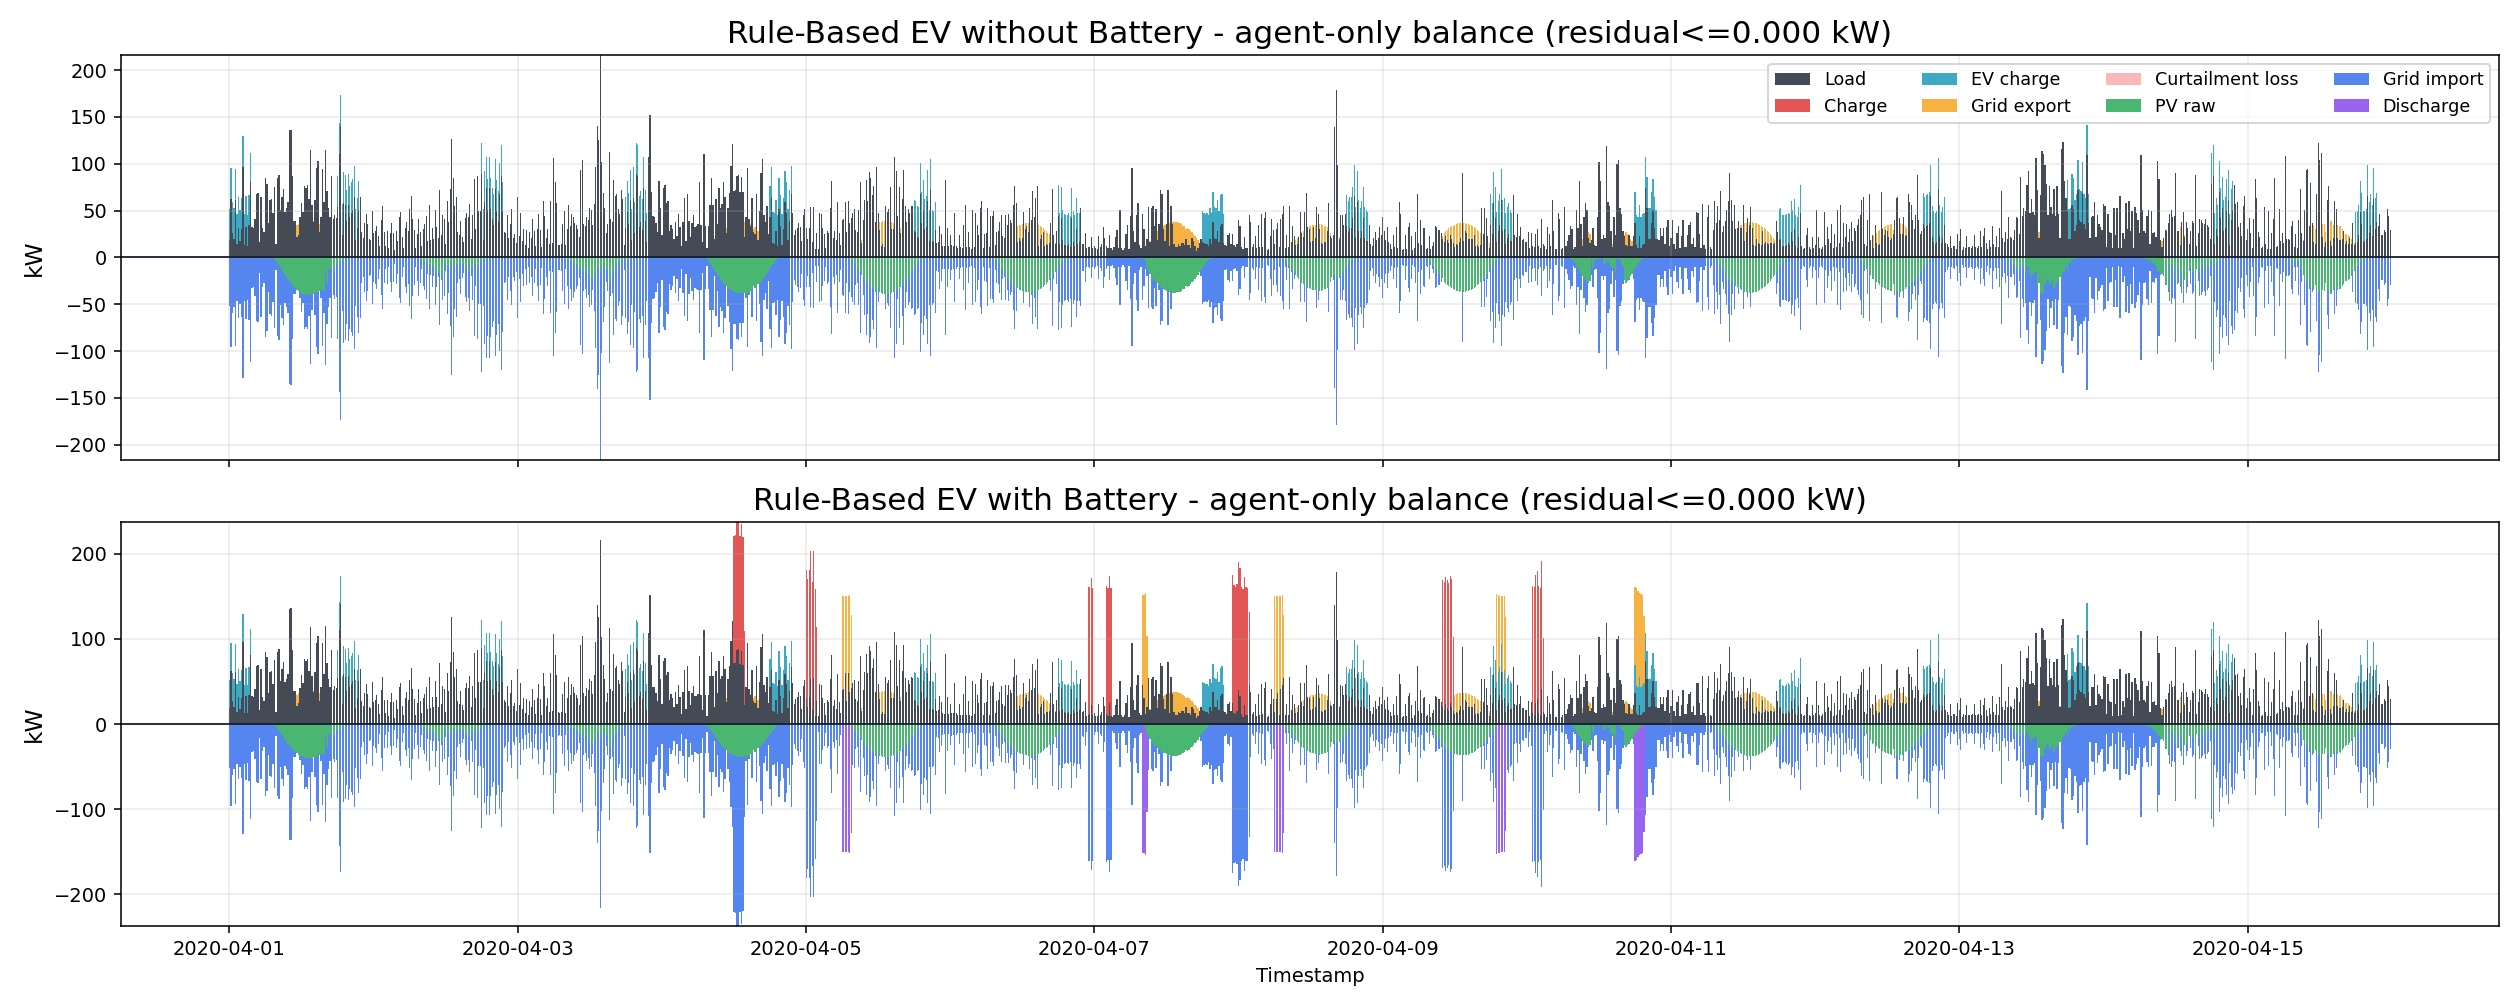

## rule_based_price

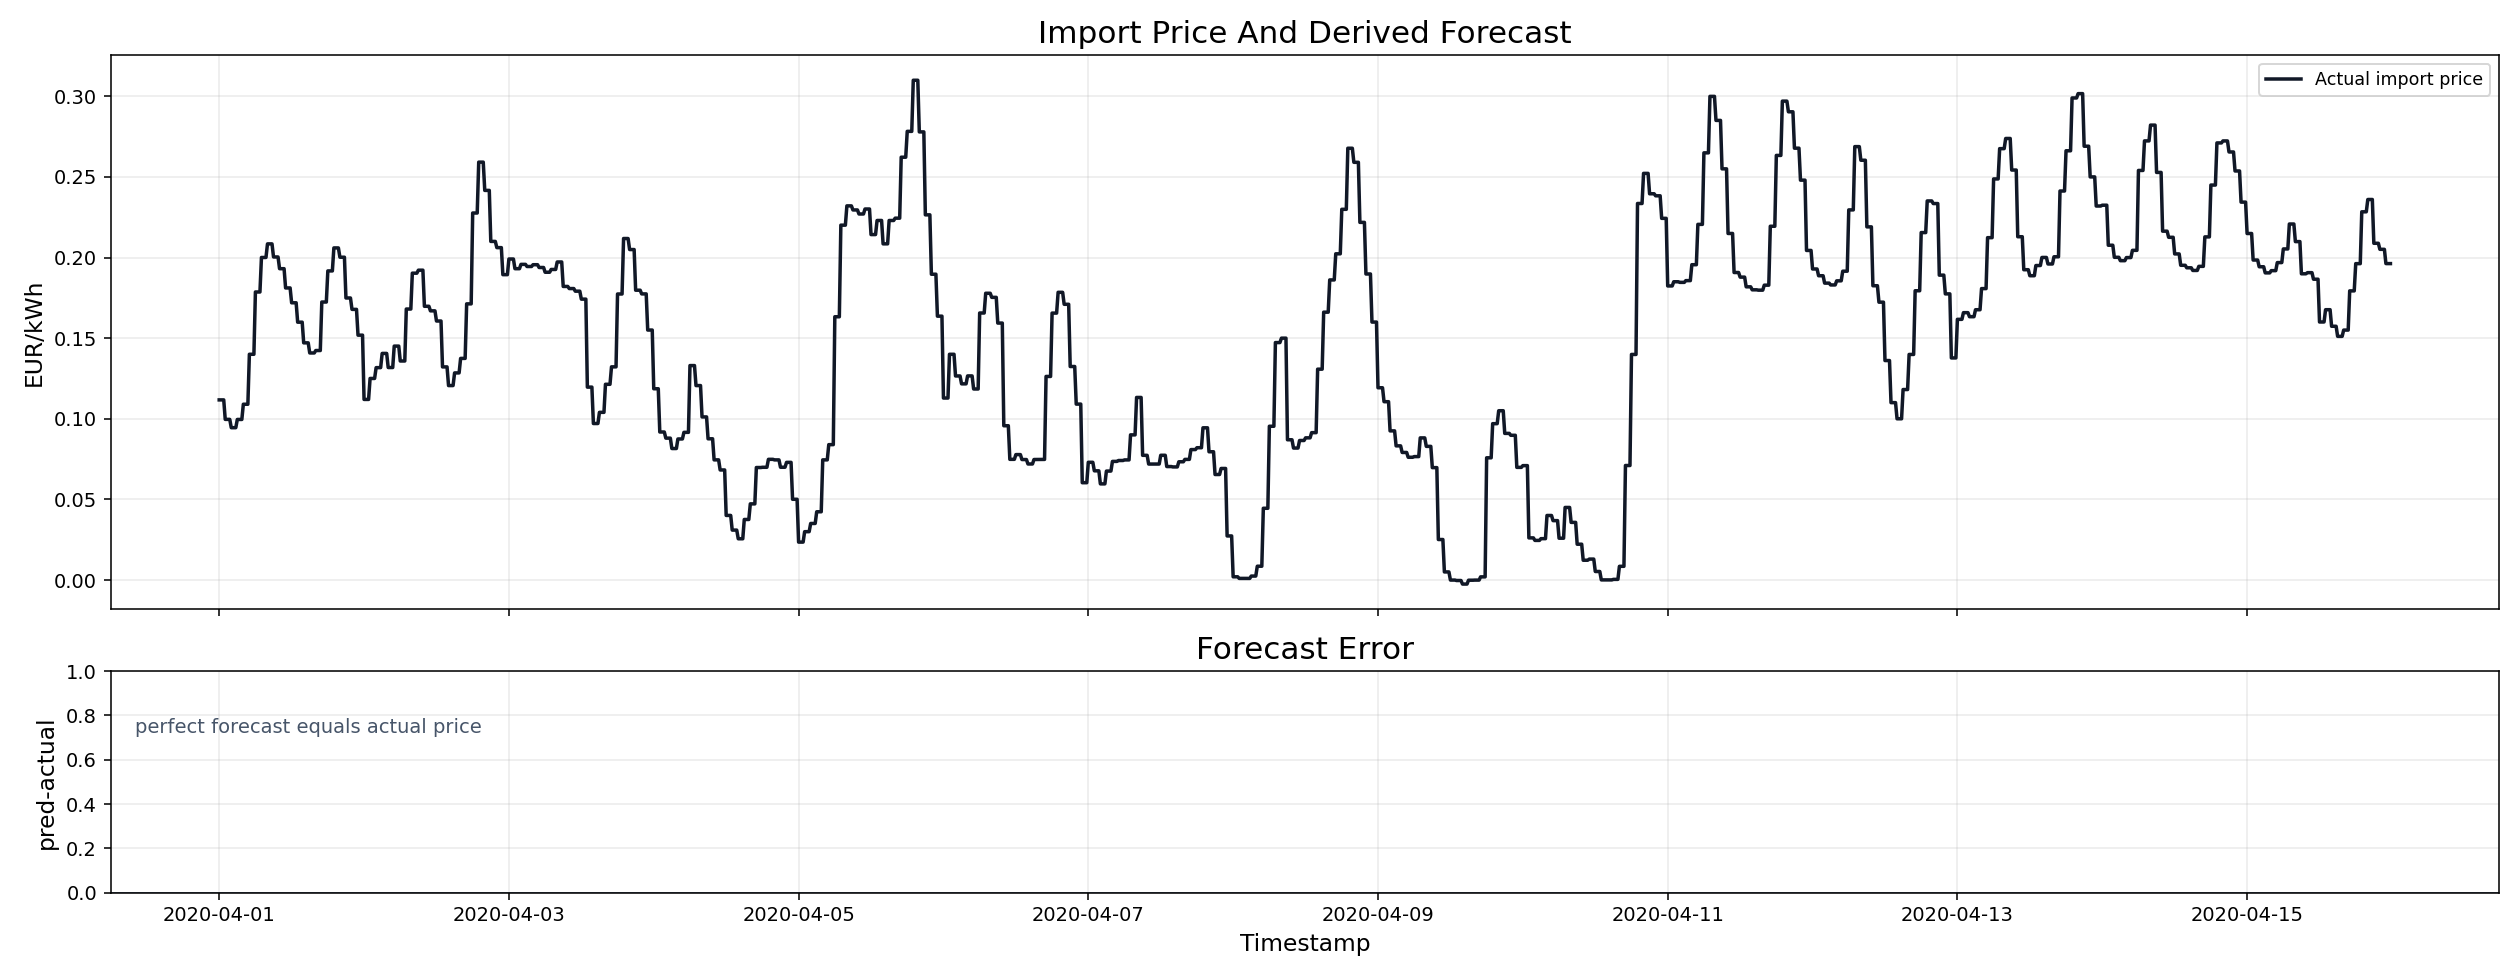

## rule_based_battery_soc

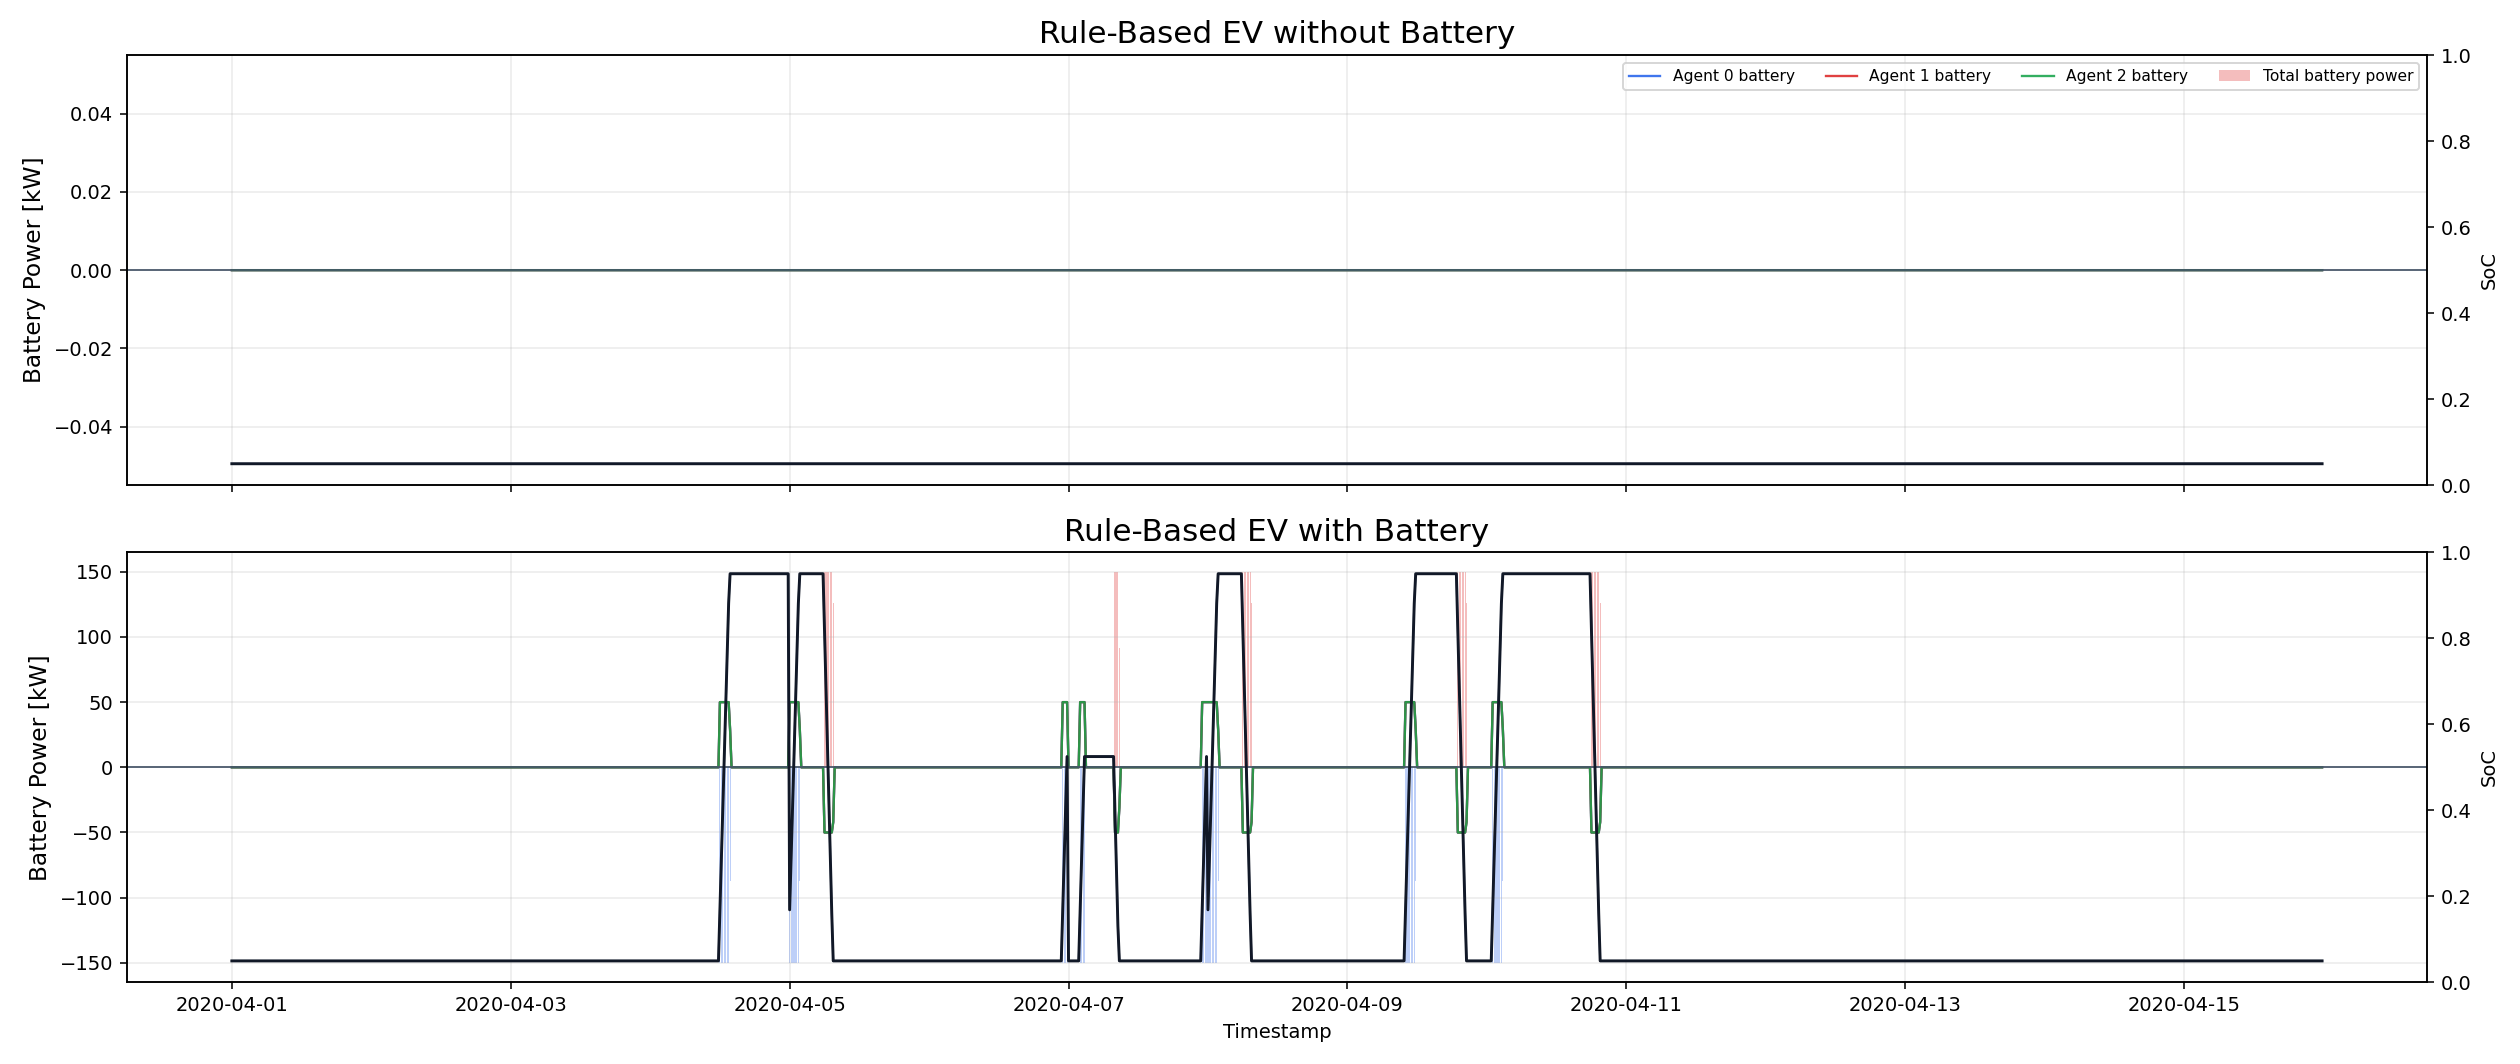

## rule_based_voltage

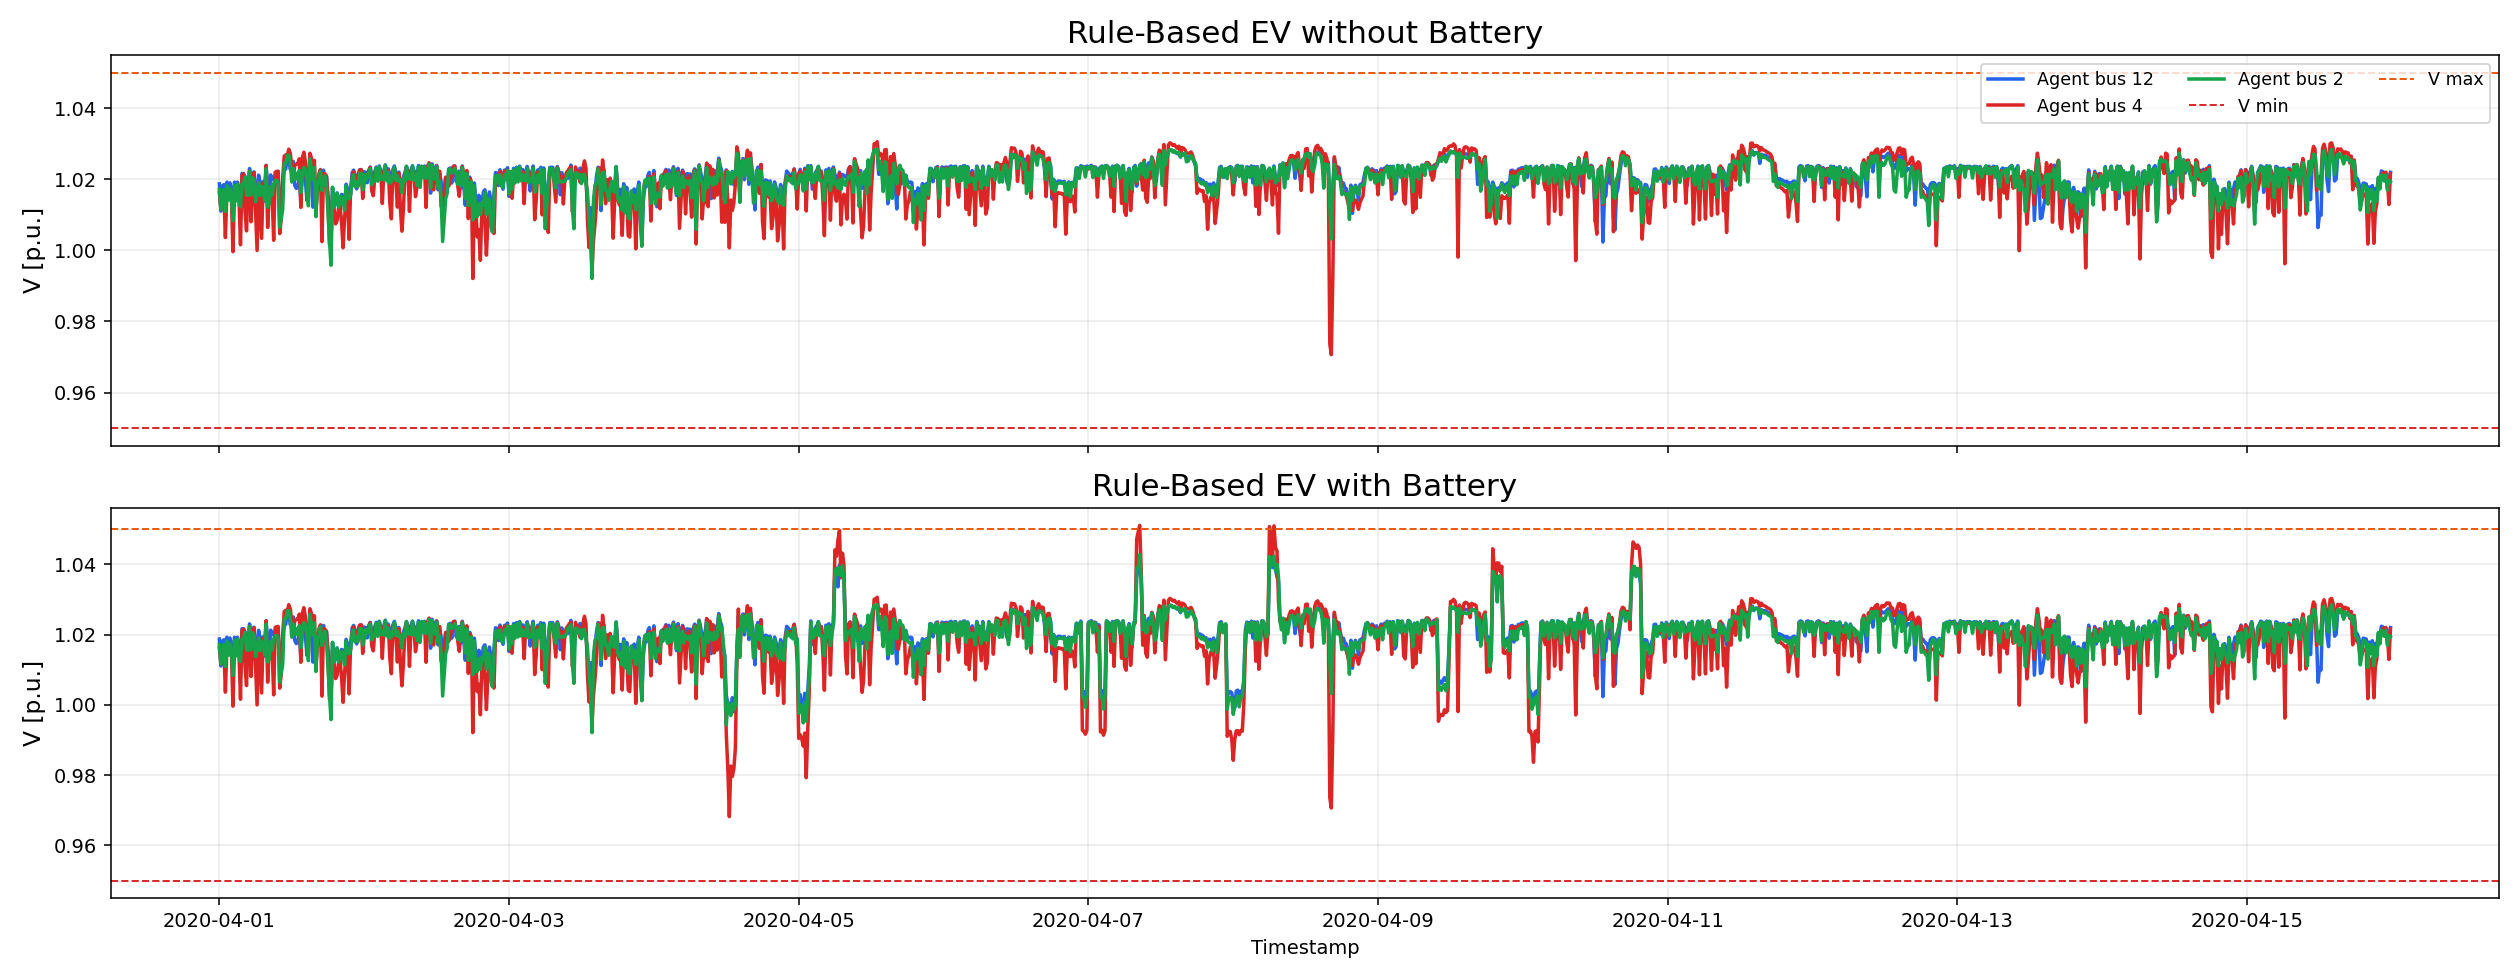

## rule_based_net_load

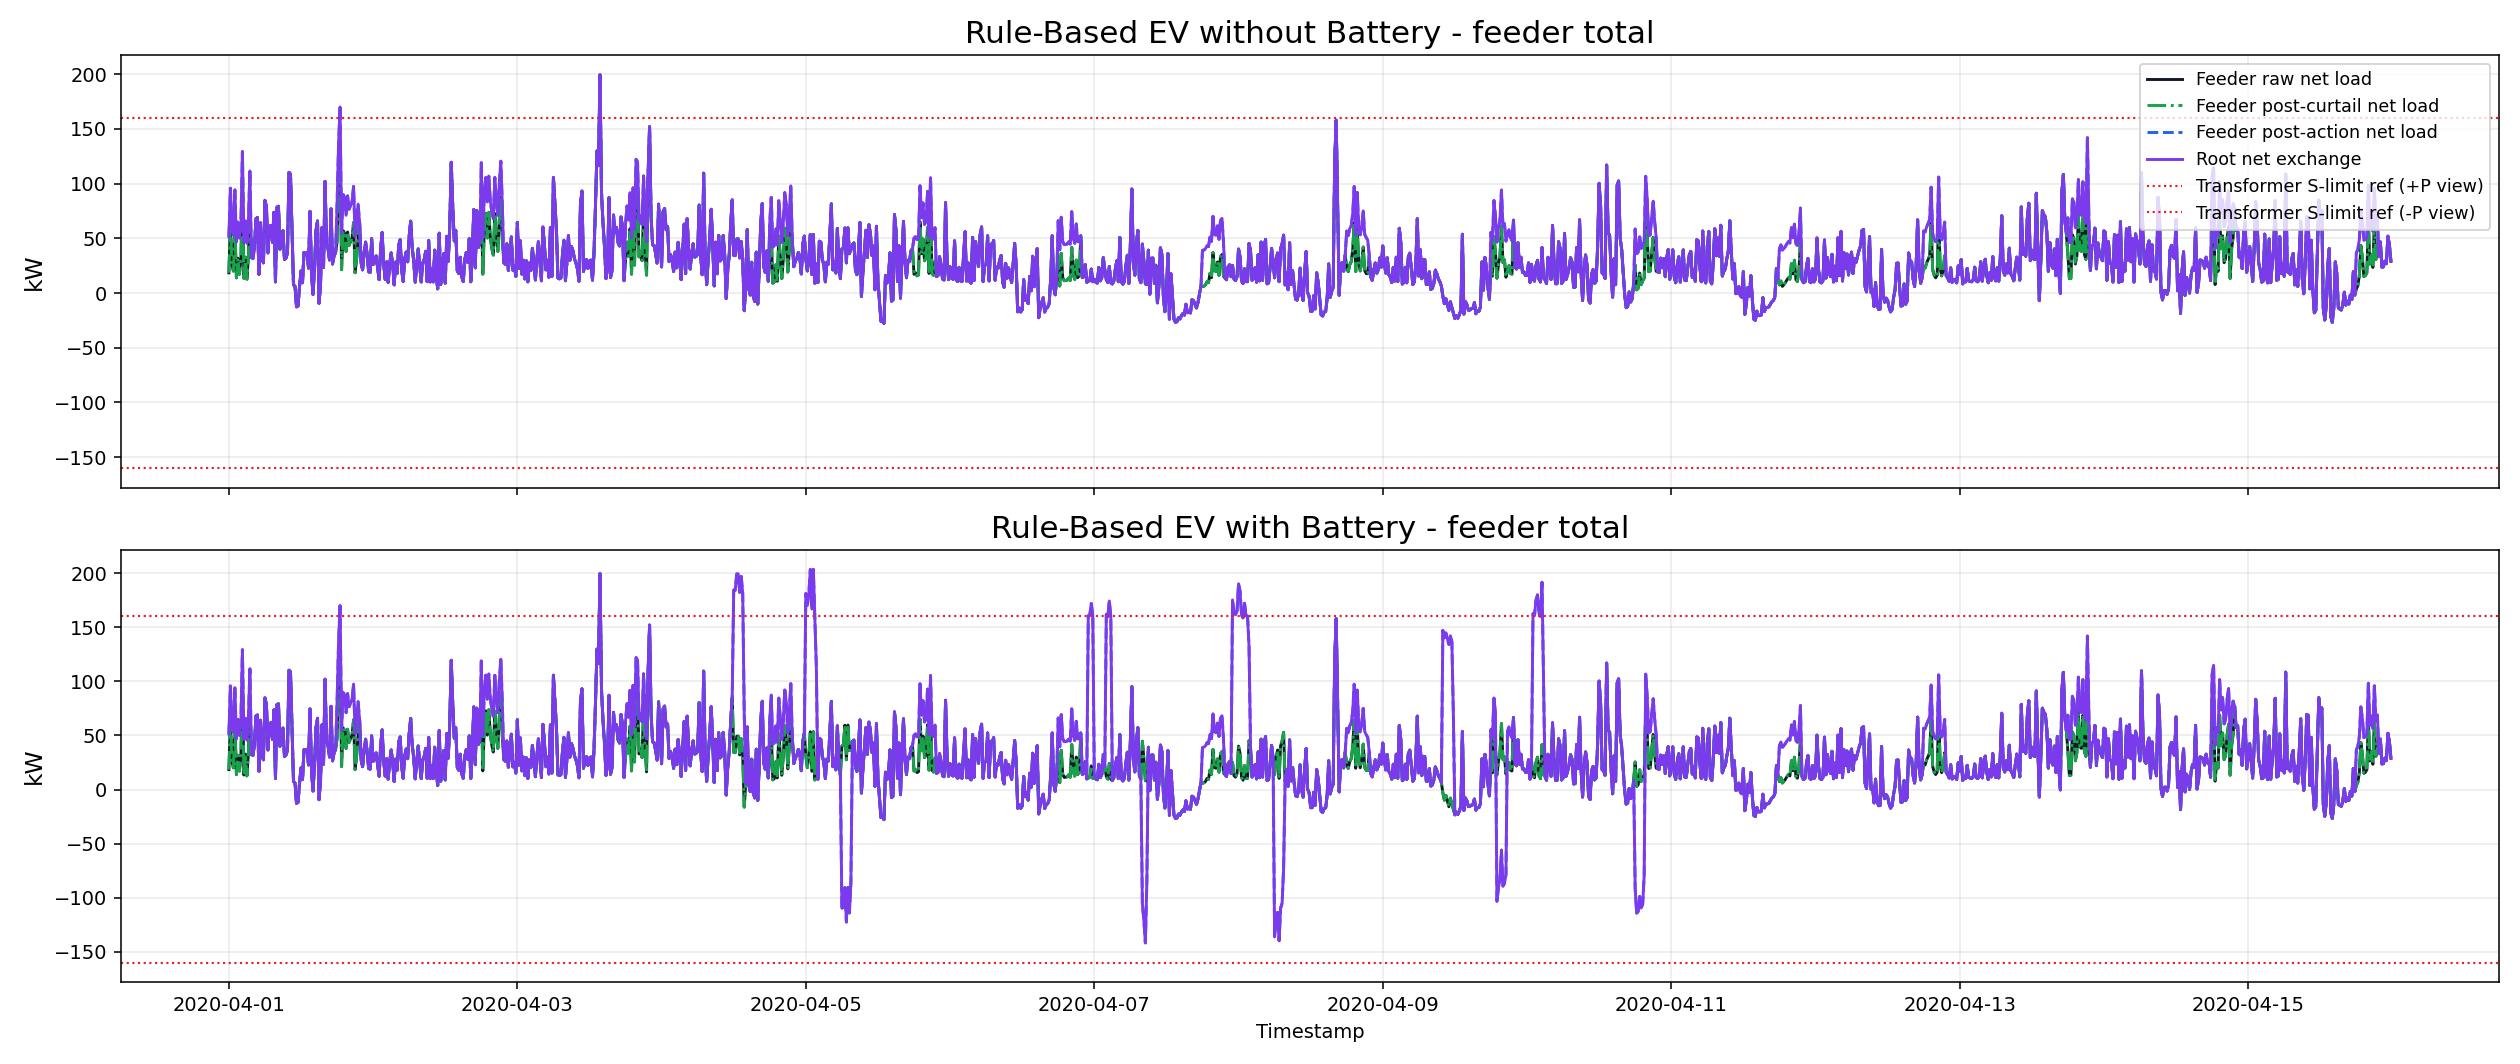

## rule_based_ev_soc

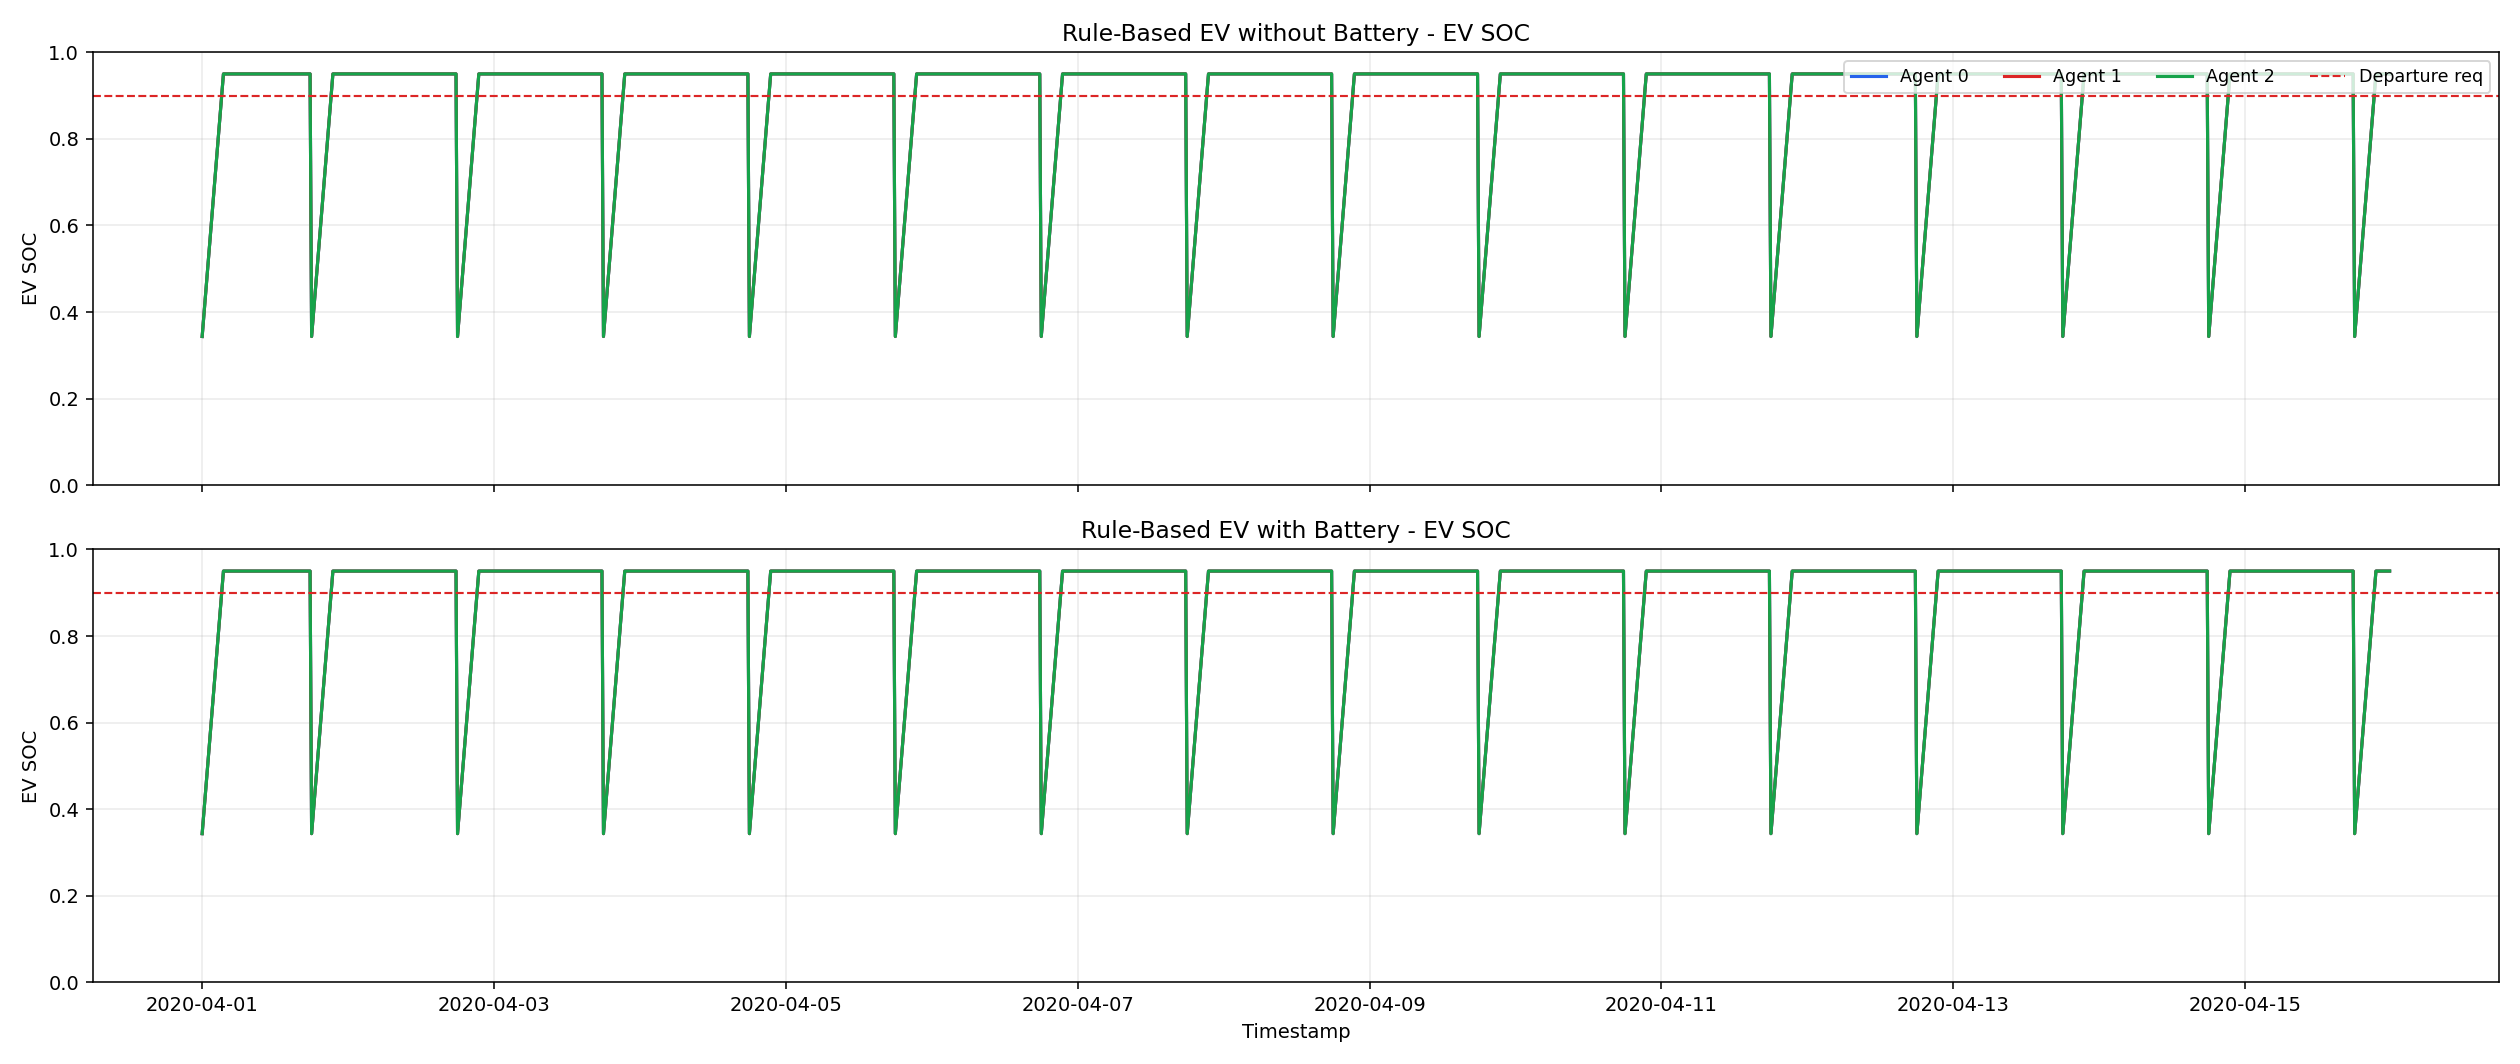

## rule_based_ev_charge_kw

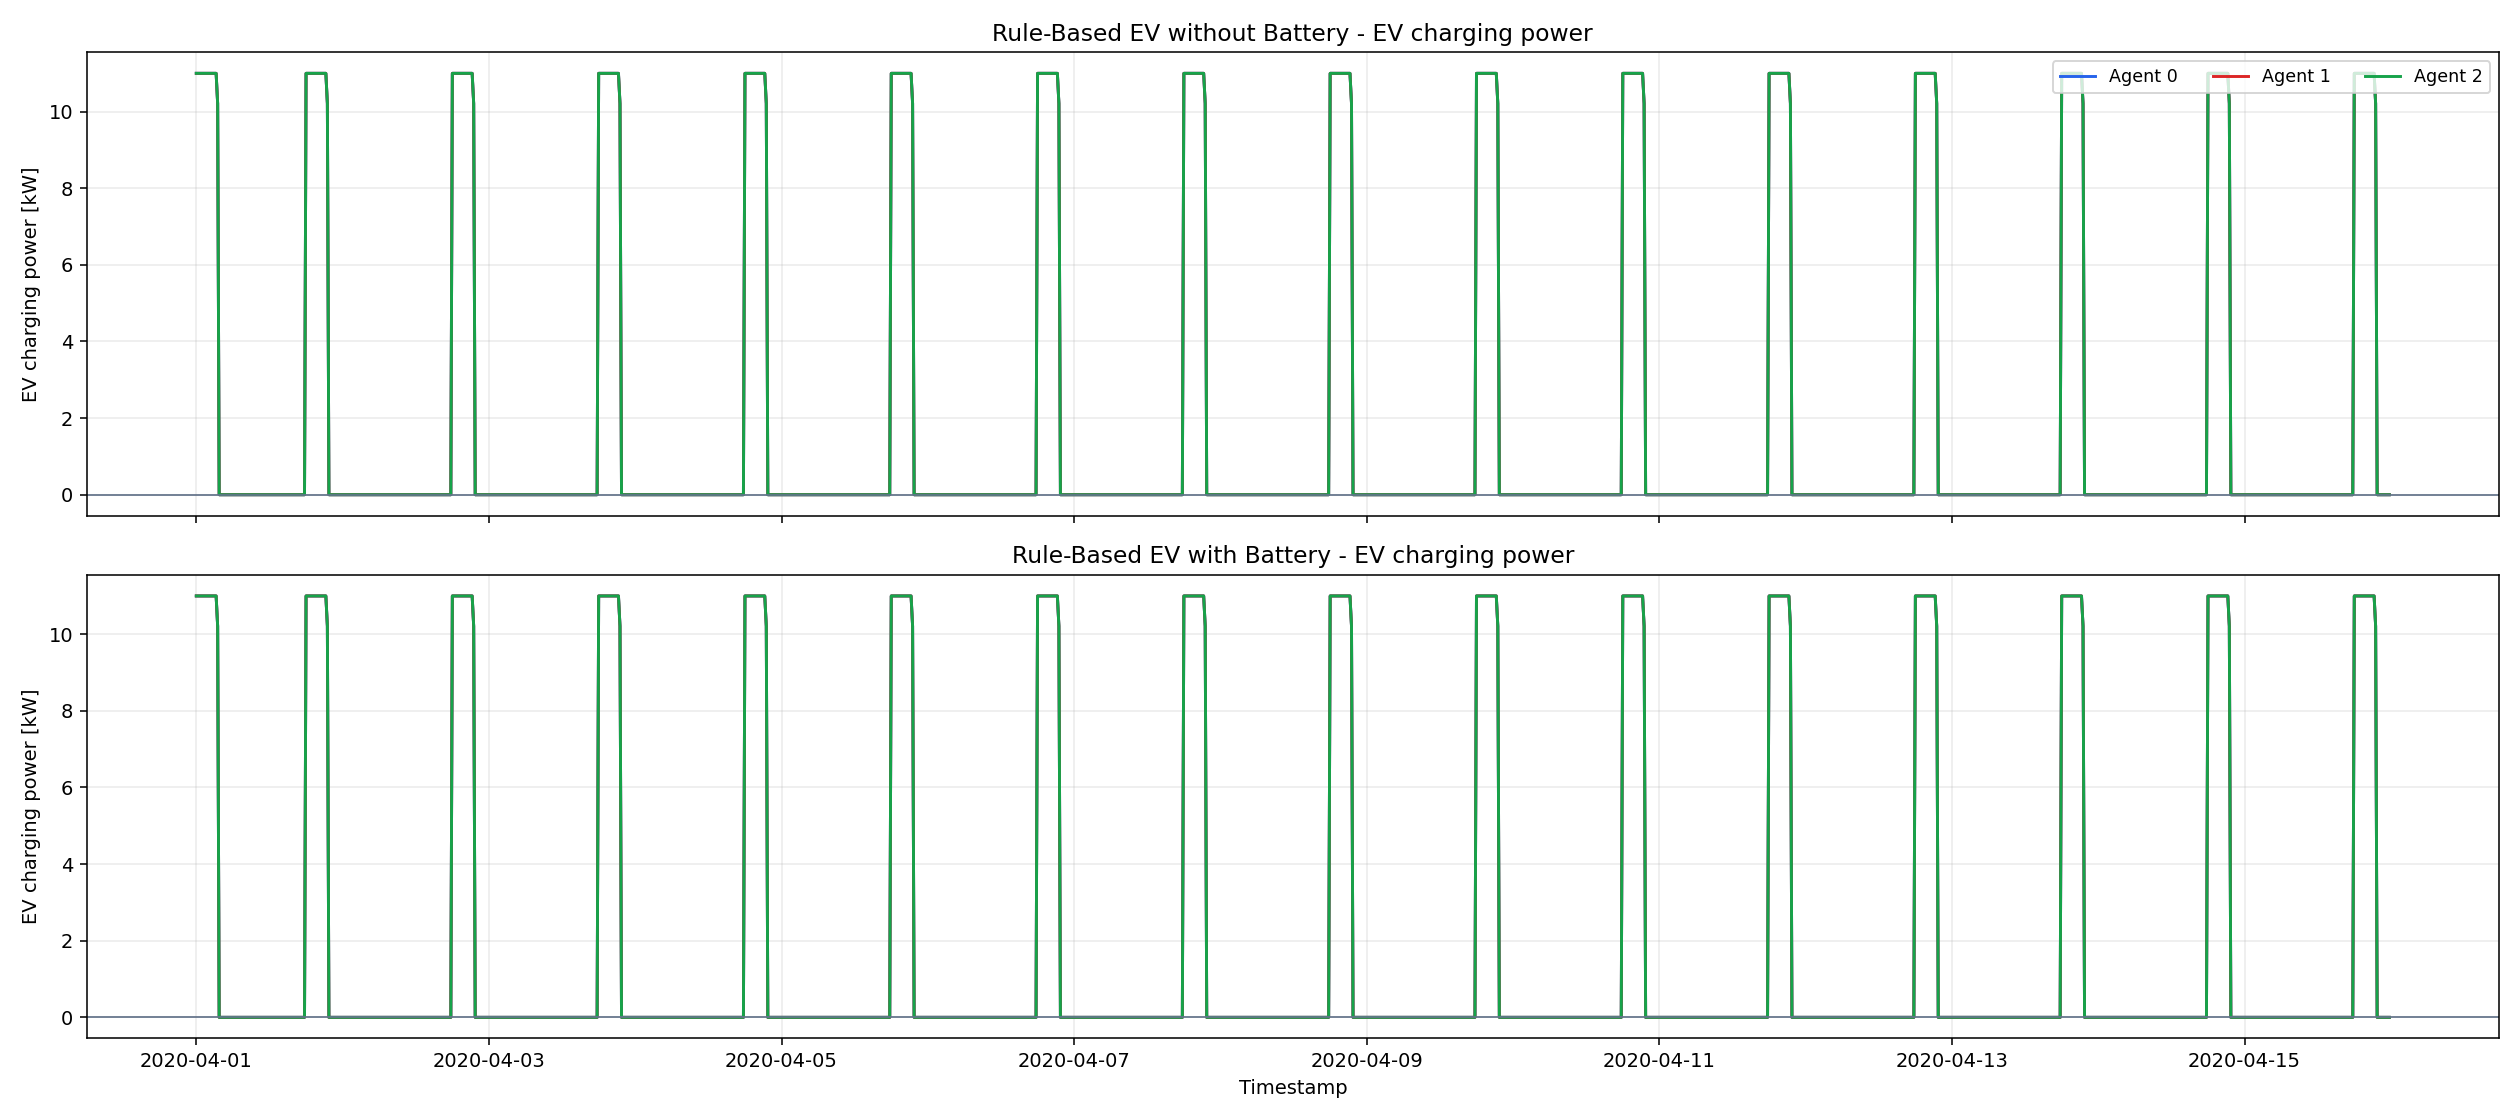

## rule_based_ev_departure_check

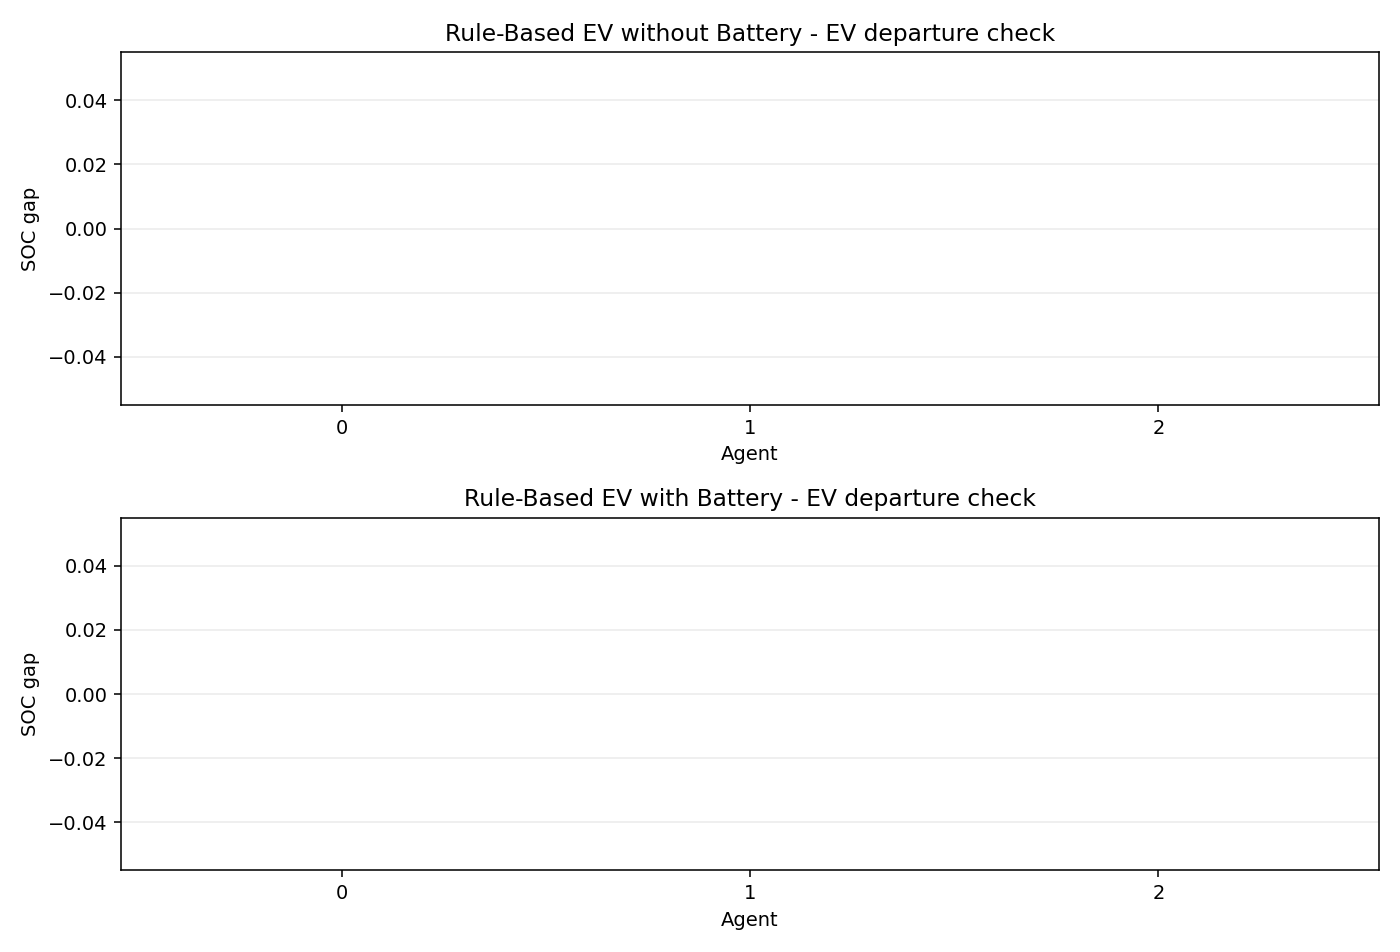

## rule_based_total_cost

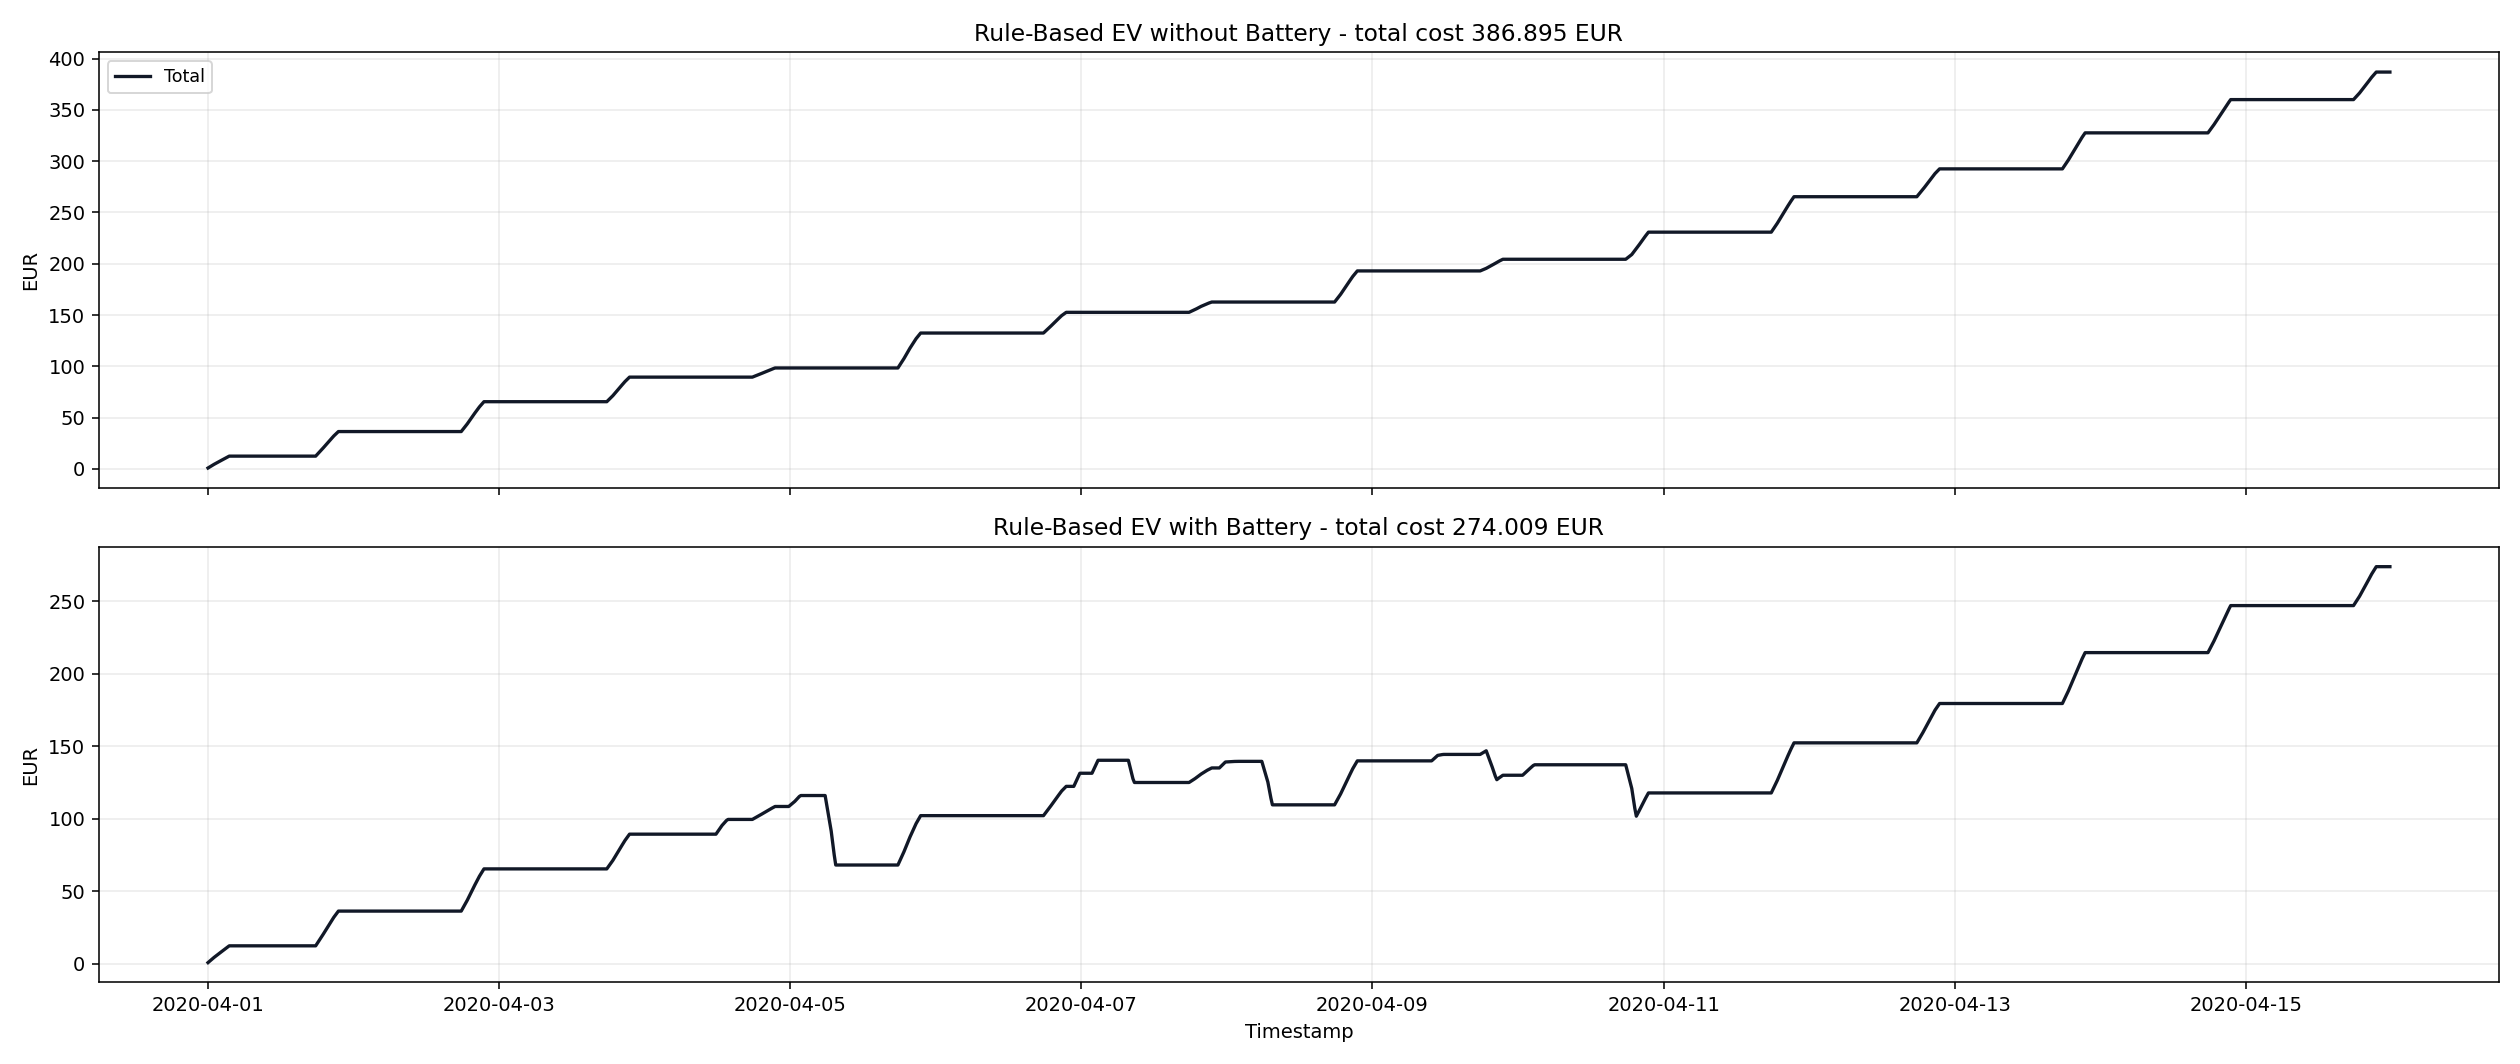

## rule_based_cost_components

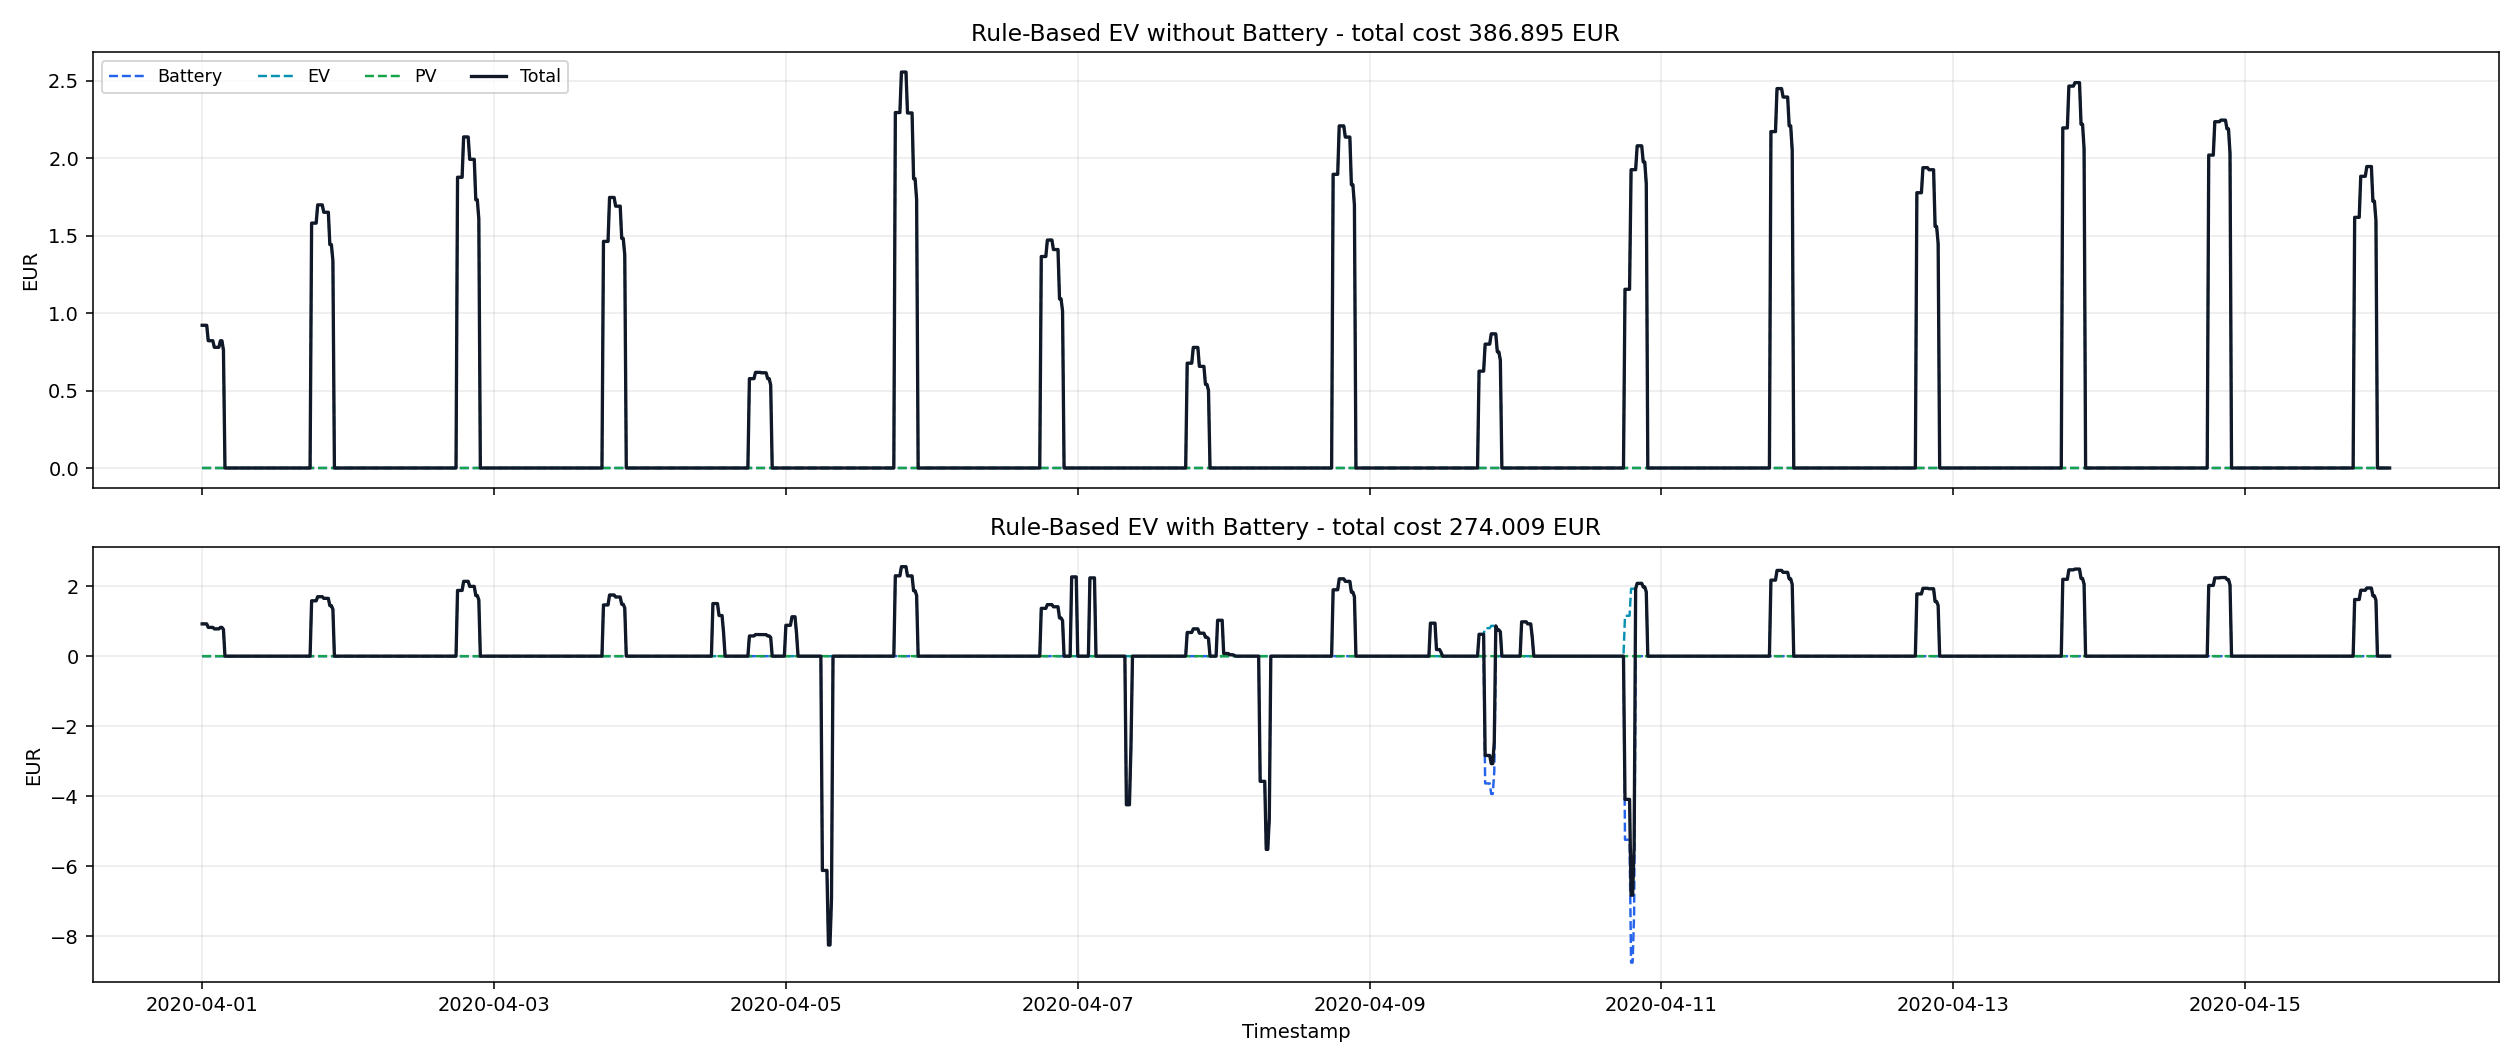

## rule_based_cumulative_cost_components

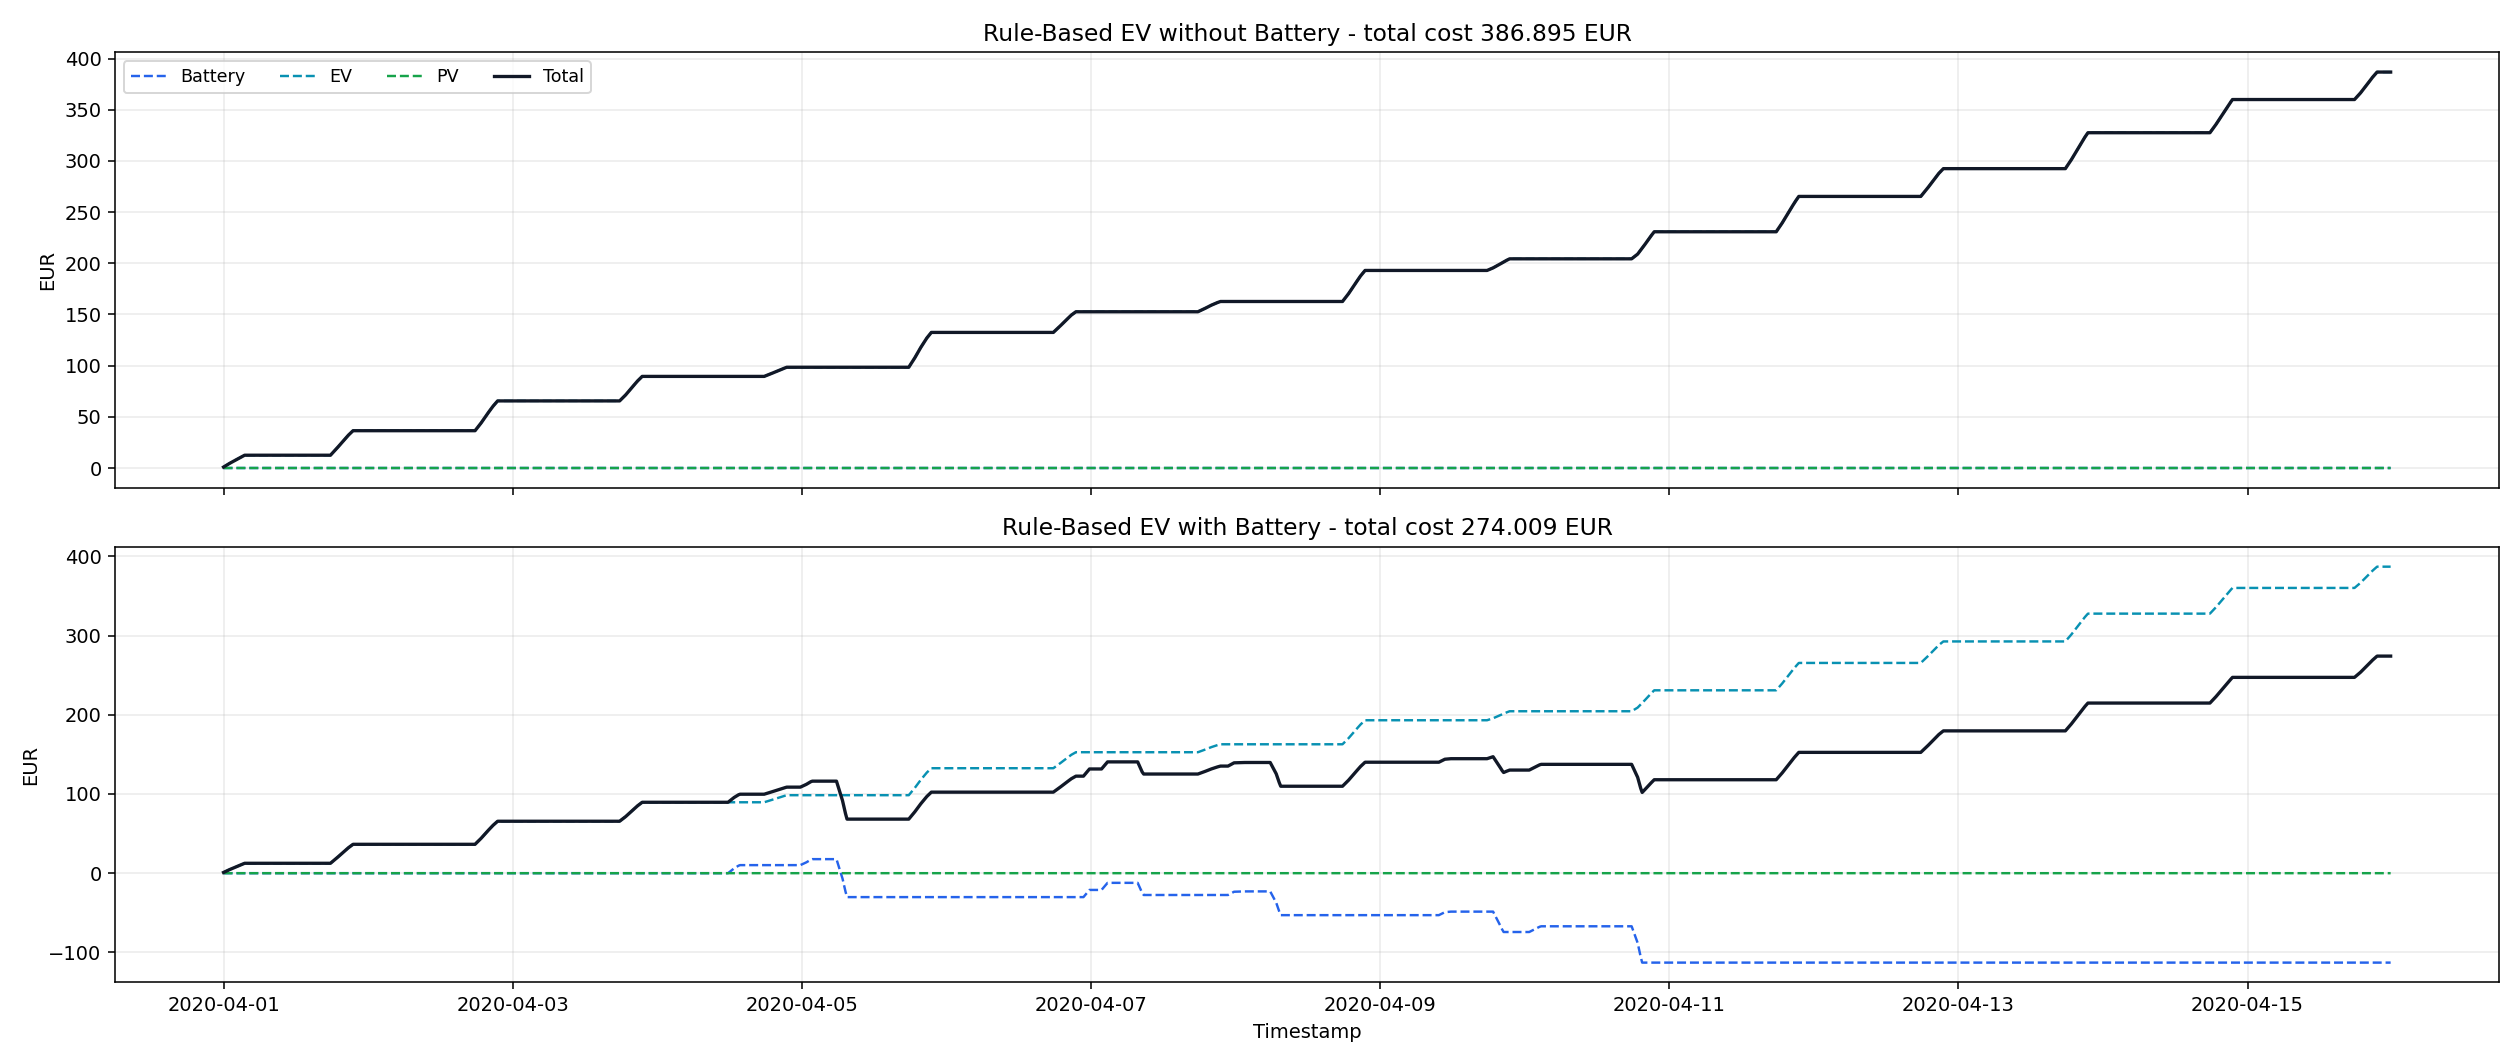

## rule_based_battery_power_price

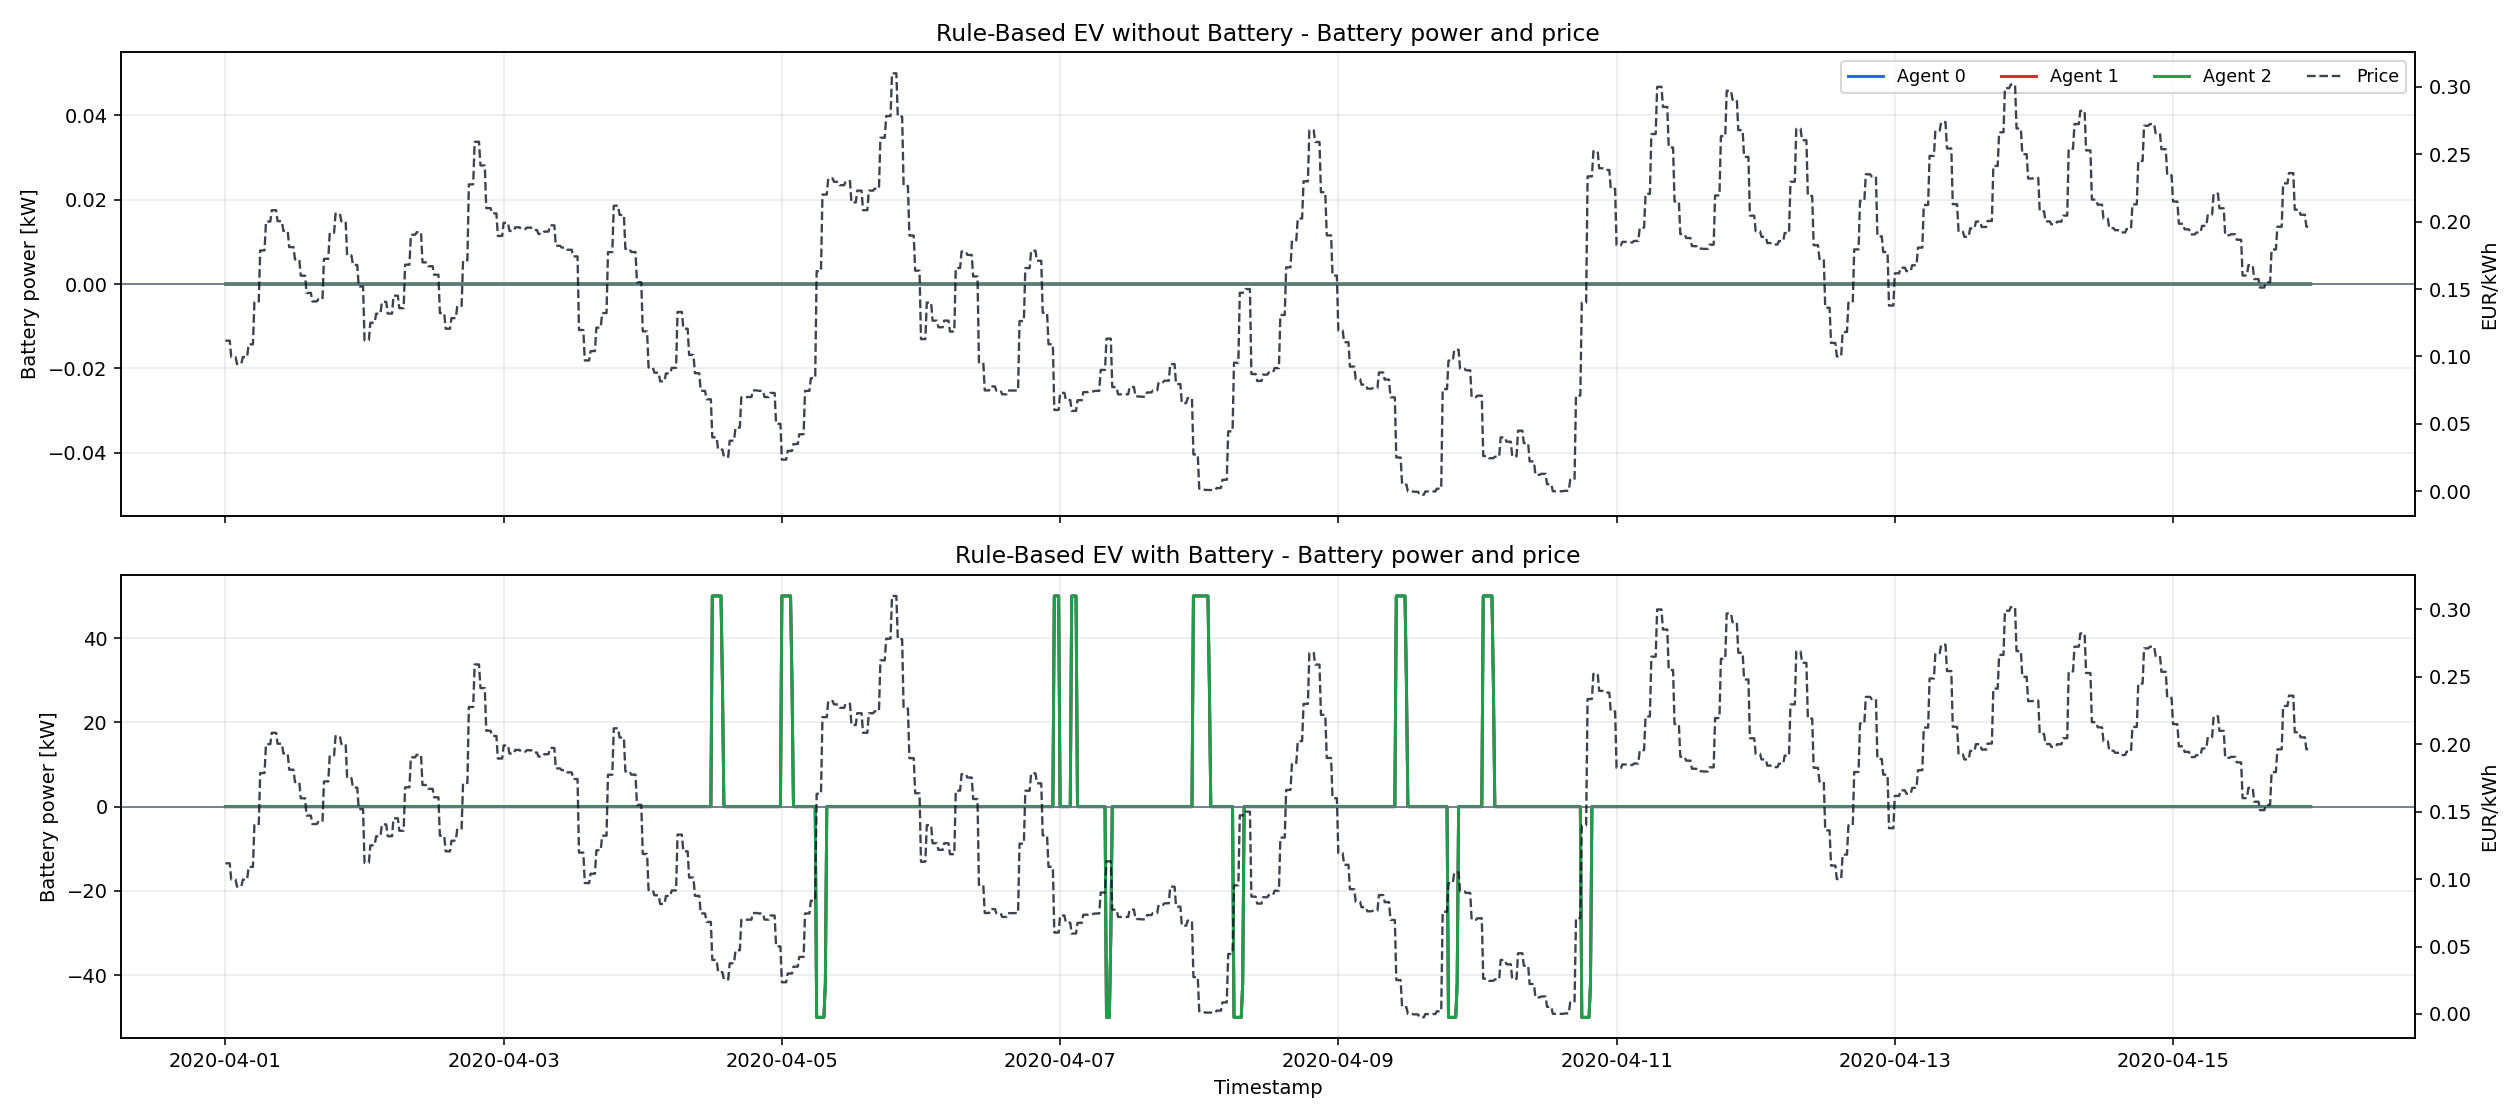

## rule_based_ev_charge_price

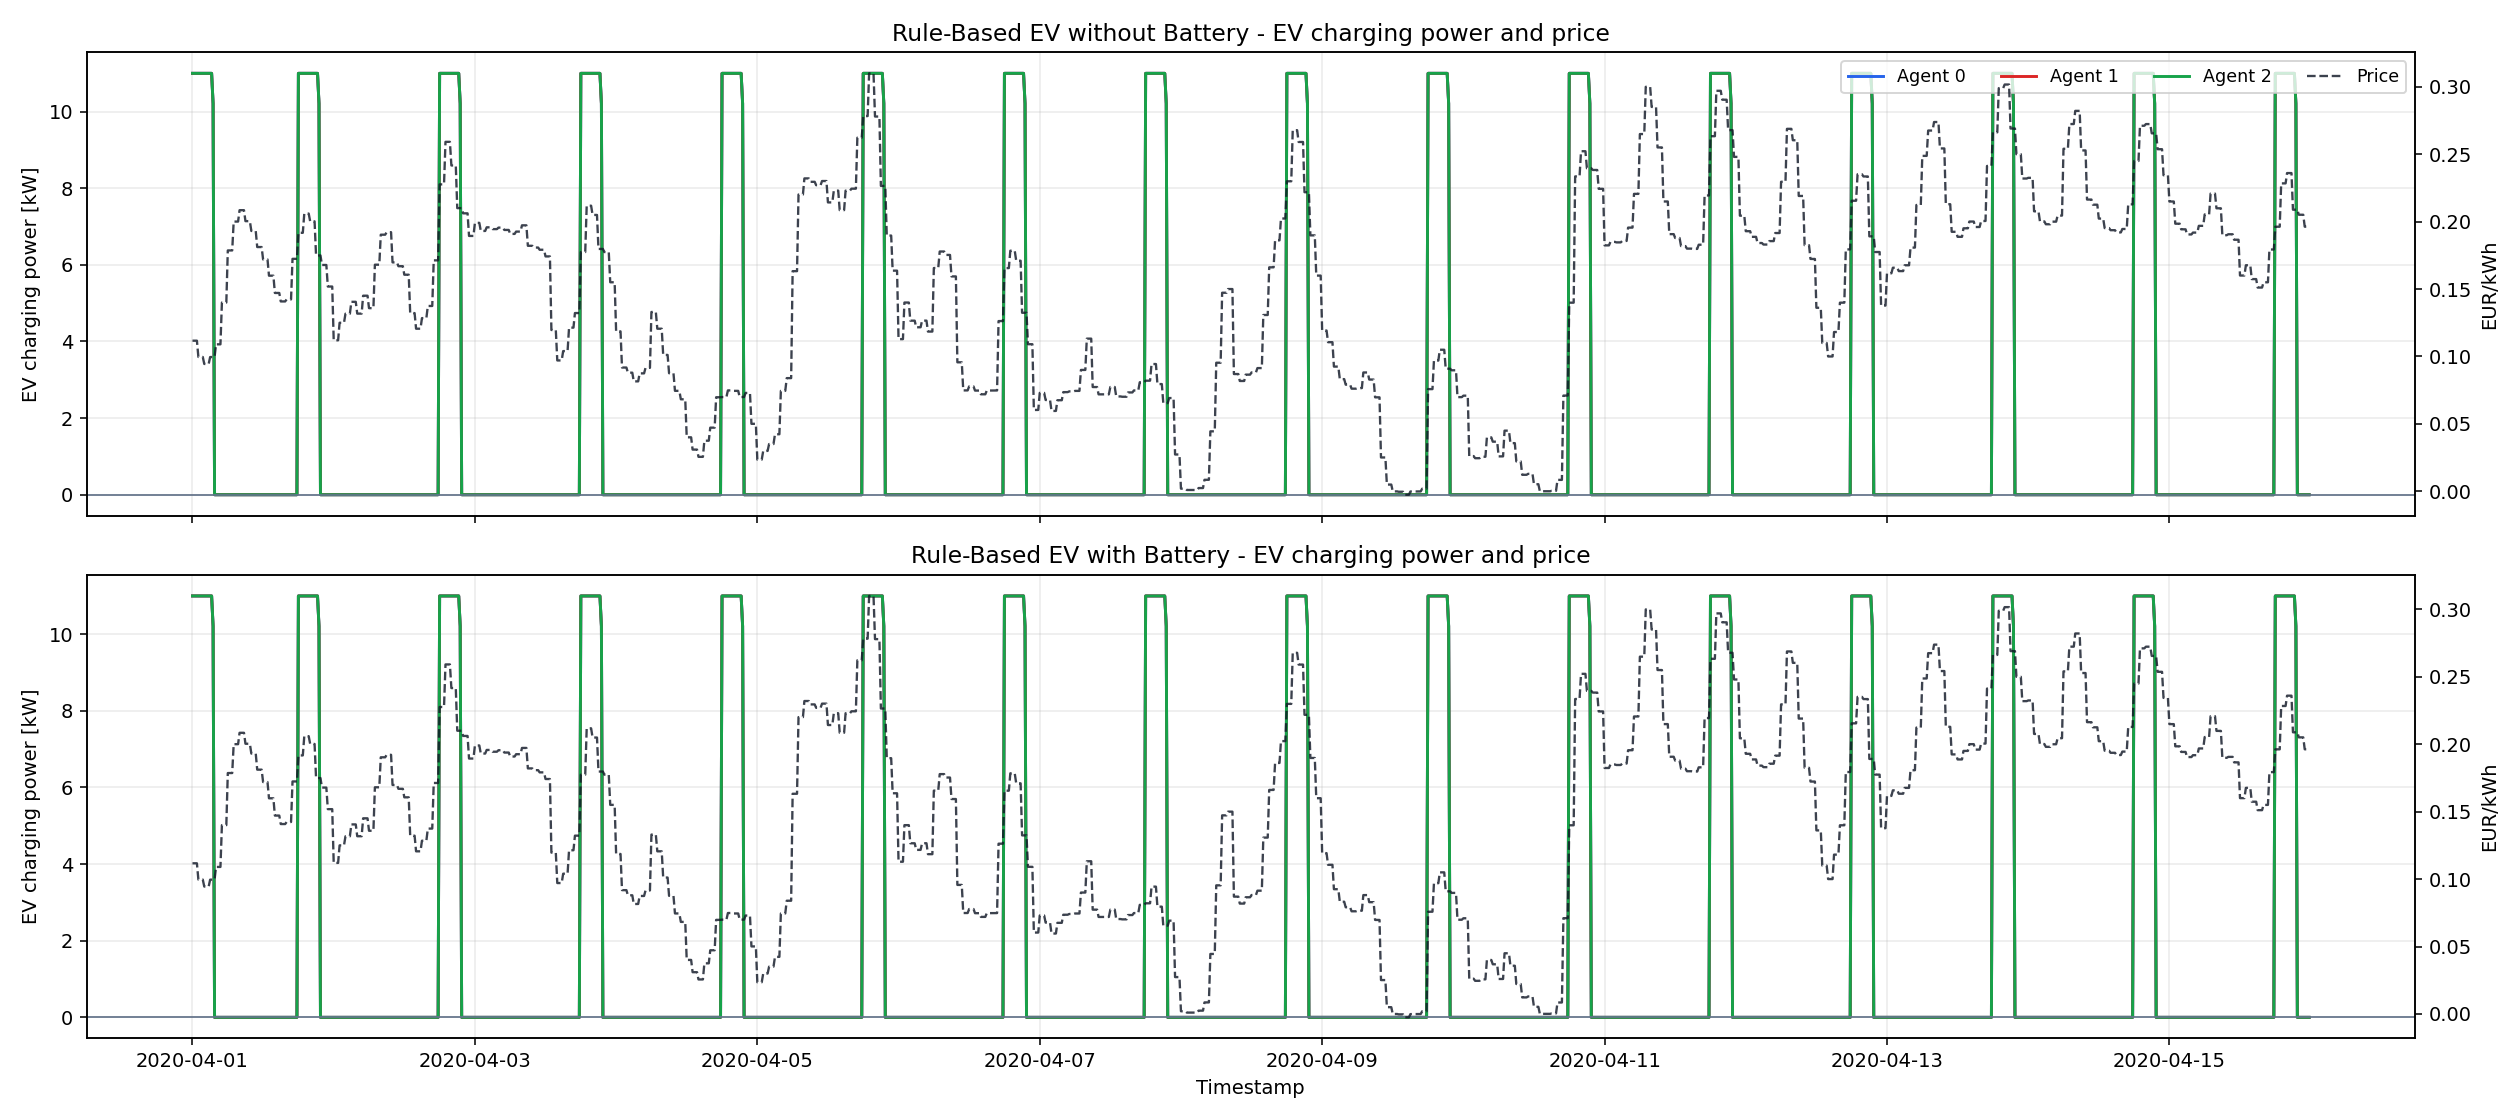

In [5]:
figure_names = [
    "rule_based_power_balance",
    "rule_based_price",
    "rule_based_battery_soc",
    "rule_based_voltage",
    "rule_based_net_load",
    "rule_based_ev_soc",
    "rule_based_ev_charge_kw",
    "rule_based_ev_departure_check",
    "rule_based_total_cost",
    "rule_based_cost_components",
    "rule_based_cumulative_cost_components",
    "rule_based_battery_power_price",
    "rule_based_ev_charge_price",
]

for name in figure_names:
    path = run_dir / "figures" / f"{name}.png"
    if path.exists():
        display(Markdown(f"## {name}"))
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"Missing figure: `{path}`"))
